In [ ]:
import os
import logging

# Придушення всіх можливих логів
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
os.environ['TF_LOGGING_VERBOSITY'] = '0'
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['CUDA_LOG_LEVEL'] = 'ERROR'
os.environ['TF_DISABLE_MKL'] = '1'
os.environ['XLA_LOG_LEVEL'] = 'ERROR'
os.environ['XLA_FLAGS'] = '--xla_gpu_strict_conv_algorithm_picker=false --xla_disable_hlo_passes=spill-heuristics'

logging.getLogger('tensorflow').setLevel(logging.ERROR)
logging.getLogger('absl').setLevel(logging.ERROR)

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="keras")

In [ ]:
!pip install kagglehub

import kagglehub
import os
import matplotlib.pyplot as plt
import warnings
from tensorflow.keras import mixed_precision
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

mixed_precision.set_global_policy('mixed_float16')

E0000 00:00:1745076371.059535  224739 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1745076371.061744  224739 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1745076371.067148  224739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745076371.067156  224739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745076371.067157  224739 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1745076371.067157  224739 computation_placer.cc:177] computation placer already registered. Please check linka

In [ ]:
diseased_base_path = kagglehub.dataset_download("ismailpromus/skin-diseases-image-dataset")
clean_path = kagglehub.dataset_download("ahdasdwdasd/our-normal-skin")

diseased_path = os.path.join(diseased_base_path, "IMG_CLASSES")

print("Path to diseased dataset files:", diseased_path)
print("Path to clean dataset files:", clean_path)

Path to diseased dataset files: /home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES
Path to clean dataset files: /home/jovyan/.cache/kagglehub/datasets/ahdasdwdasd/our-normal-skin/versions/2


In [ ]:
for path in [diseased_path, clean_path]:
    for root, dirs, files in os.walk(path):
        num_dirs = len(dirs)
        num_files = len(files)
        print(f"{root}: {num_files} файлів, {num_dirs} директорій")

/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES: 0 файлів, 10 директорій
/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES/1. Eczema 1677: 1677 файлів, 0 директорій
/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES/5. Melanocytic Nevi (NV) - 7970: 7970 файлів, 0 директорій
/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES/7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055 файлів, 0 директорій
/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES/9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702 файлів, 0 директорій
/home/jovyan/.cache/kagglehub/datasets/ismailpromus/skin-diseases-image-dataset/versions/1/IMG_CLASSES/3. Atopic Dermatitis - 1.25k: 1257 файлів, 0 директорій
/home/jovyan/.cache

Розподіл зображень по класах:
5. Melanocytic Nevi (NV) - 7970: 7970 зображень (29.22%)
4. Basal Cell Carcinoma (BCC) 3323: 3323 зображень (12.18%)
2. Melanoma 15.75k: 3140 зображень (11.51%)
10. Warts Molluscum and other Viral Infections - 2103: 2103 зображень (7.71%)
6. Benign Keratosis-like Lesions (BKL) 2624: 2079 зображень (7.62%)
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2055 зображень (7.53%)
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 1847 зображень (6.77%)
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 1702 зображень (6.24%)
1. Eczema 1677: 1677 зображень (6.15%)
3. Atopic Dermatitis - 1.25k: 1257 зображень (4.61%)
Normal Skin: 124 зображень (0.45%)


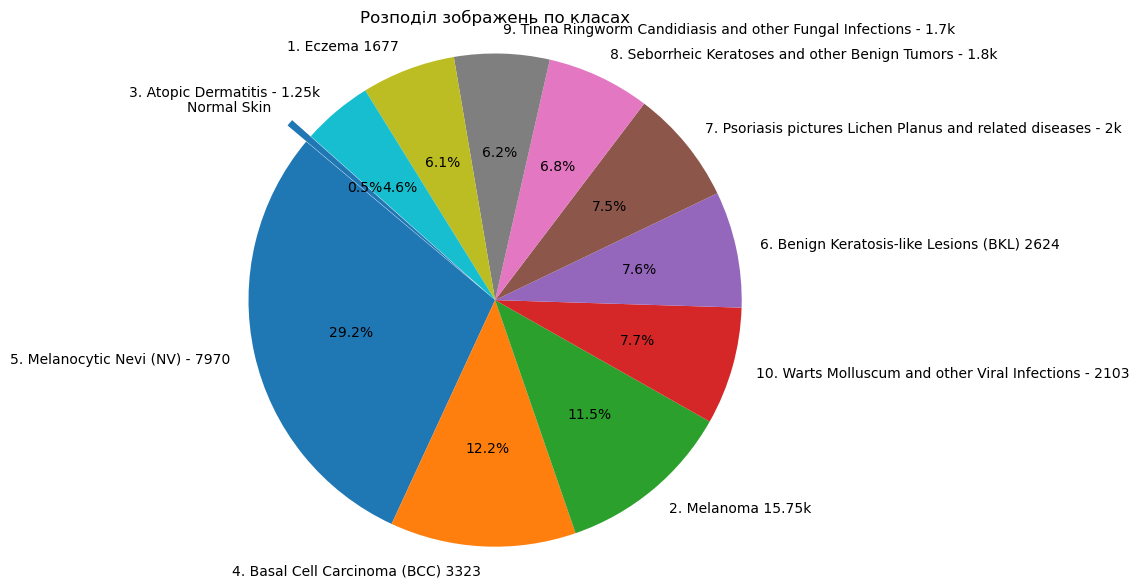

In [ ]:
import matplotlib.pyplot as plt

class_counts = {}
for class_dir in os.listdir(diseased_path):
    full_path = os.path.join(diseased_path, class_dir)
    if os.path.isdir(full_path):
        count = len(os.listdir(full_path))
        class_counts[class_dir] = count

class_counts["Normal Skin"] = len(os.listdir(clean_path))

total_images = sum(class_counts.values())

class_percentages = {k: (v / total_images) * 100 for k, v in class_counts.items()}

sorted_counts = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))
sorted_percentages = {k: class_percentages[k] for k in sorted_counts.keys()}

print("Розподіл зображень по класах:")
for name, count in sorted_counts.items():
    print(f"{name}: {count} зображень ({sorted_percentages[name]:.2f}%)")

labels = list(sorted_percentages.keys())
sizes = list(sorted_percentages.values())
explode = [0.1 if label == "Normal Skin" else 0 for label in labels]

plt.figure(figsize=(7, 7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, explode=explode)
plt.axis('equal')
plt.title("Розподіл зображень по класах")
plt.show()

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import tensorflow as tf
import shutil
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

def augment_images(images, class_path, target_count, save_path):
    """
    Аугментація зображень для досягнення цільової кількості зображень у класі.

    Ця функція використовує ImageDataGenerator для генерації нових зображень на основі існуючих,
    якщо поточна кількість зображень менша за цільову. Аугментовані зображення зберігаються у вказаній директорії.

    :param images: Список імен зображень у класі.
    :param class_path: Шлях до директорії з зображеннями класу.
    :param target_count: Цільова кількість зображень для класу.
    :param save_path: Шлях для збереження аугментованих зображень.
    :return: Список імен зображень, включаючи оригінальні та аугментовані.
    """
    datagen = ImageDataGenerator(
        rotation_range=40,
        width_shift_range=0.3,
        height_shift_range=0.3,
        shear_range=0.3,
        zoom_range=0.3,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest'
    )

    current_count = len(images)
    if current_count >= target_count:
        return images
    images_to_generate = target_count - current_count
    augmented_images = []
    for img_name in images:
        img_path = os.path.join(class_path, img_name)
        img = plt.imread(img_path)
        if img.shape[-1] == 4:
            img = img[..., :3]
        img = np.expand_dims(img, axis=0)
        for i, batch in enumerate(datagen.flow(img, batch_size=1, save_to_dir=None)):
            aug_img = batch[0].astype('uint8')
            aug_img_name = f"aug_{len(augmented_images)}_{img_name}"
            augmented_images.append(aug_img_name)
            plt.imsave(os.path.join(save_path, aug_img_name), aug_img)
            if len(augmented_images) >= images_to_generate:
                break
        if len(augmented_images) >= images_to_generate:
            break
    return images + augmented_images

In [ ]:
import os
import shutil
import random

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

def prepare_dataset(source_paths, target_train, target_val, target_test, base_target_size=4000, val_ratio=0.2, test_ratio=0.2):
    for target in [target_train, target_val, target_test]:
        if os.path.exists(target):
            shutil.rmtree(target)
        os.makedirs(target, exist_ok=True)
    print(f"Створено директорії: {target_train}, {target_val}, {target_test}")

    for source in source_paths:
        is_normal_skin = "our-normal-skin" in source
        source_dirs = [source] if is_normal_skin else os.listdir(source)

        for class_dir in source_dirs:
            class_path = source if is_normal_skin else os.path.join(source, class_dir)
            if not os.path.isdir(class_path):
                continue

            class_name = "Normal Skin" if is_normal_skin else class_dir
            images = [img for img in os.listdir(class_path) if img.endswith(('.jpg', '.png', '.jpeg'))]
            temp_path = None

            target_size = base_target_size

            if len(images) < target_size:
                temp_path = os.path.join(target_train, f"temp_{class_name}")
                os.makedirs(temp_path, exist_ok=True)
                for img in images:
                    shutil.copy(os.path.join(class_path, img), os.path.join(temp_path, img))
                images = augment_images(images, class_path, target_count=target_size, save_path=temp_path)
            elif len(images) > target_size:
                images = random.sample(images, target_size)

            random.shuffle(images)
            total_images = len(images)
            test_size = max(1, int(total_images * test_ratio))
            val_size = max(1, int(total_images * val_ratio))
            train_size = total_images - test_size - val_size

            train_class_path = os.path.join(target_train, class_name)
            val_class_path = os.path.join(target_val, class_name)
            test_class_path = os.path.join(target_test, class_name)
            os.makedirs(train_class_path, exist_ok=True)
            os.makedirs(val_class_path, exist_ok=True)
            os.makedirs(test_class_path, exist_ok=True)

            train_copied = 0
            val_copied = 0
            test_copied = 0
            for i, img in enumerate(images):
                src = os.path.join(temp_path if temp_path else class_path, img)
                if i < train_size:
                    dst = os.path.join(train_class_path, img)
                    train_copied += 1
                elif i < train_size + val_size:
                    dst = os.path.join(val_class_path, img)
                    val_copied += 1
                else:
                    dst = os.path.join(test_class_path, img)
                    test_copied += 1
                shutil.copy(src, dst)

            print(f"Скопійовано для {class_name}: {train_copied} у train, {val_copied} у validation, {test_copied} у test")
            if temp_path:
                shutil.rmtree(temp_path)

    print("\nПеревірка розмірів класів:")
    for dataset, name in [(target_train, "train"), (target_val, "validation"), (target_test, "test")]:
        print(f"\n{name.capitalize()} набір:")
        for class_dir in sorted(os.listdir(dataset)):
            class_path = os.path.join(dataset, class_dir)
            if os.path.isdir(class_path):
                count = len(os.listdir(class_path))
                print(f"{class_dir}: {count} зображень")

    print("\nДатасет підготовлено.")


prepare_dataset(
    [diseased_path, clean_path],
    "/home/jovyan/work/dataset/train",
    "/home/jovyan/work/dataset/validation",
    "/home/jovyan/work/dataset/test",
    base_target_size=4000,
    val_ratio=0.2,
    test_ratio=0.2
)

Створено директорії: /home/jovyan/work/dataset/train, /home/jovyan/work/dataset/validation, /home/jovyan/work/dataset/test
Скопійовано для 1. Eczema 1677: 2400 у train, 800 у validation, 800 у test
Скопійовано для 5. Melanocytic Nevi (NV) - 7970: 2400 у train, 800 у validation, 800 у test
Скопійовано для 7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2400 у train, 800 у validation, 800 у test
Скопійовано для 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 2400 у train, 800 у validation, 800 у test
Скопійовано для 3. Atopic Dermatitis - 1.25k: 2400 у train, 800 у validation, 800 у test
Скопійовано для 4. Basal Cell Carcinoma (BCC) 3323: 2400 у train, 800 у validation, 800 у test
Скопійовано для 10. Warts Molluscum and other Viral Infections - 2103: 2400 у train, 800 у validation, 800 у test
Скопійовано для 6. Benign Keratosis-like Lesions (BKL) 2624: 2400 у train, 800 у validation, 800 у test
Скопійовано для 2. Melanoma 15.75k: 2400 у train, 800 у valid

Розподіл зображень по класах після under-/oversampling (тренувальний набір):
1. Eczema 1677: 2400 зображень (9.09%)
5. Melanocytic Nevi (NV) - 7970: 2400 зображень (9.09%)
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2400 зображень (9.09%)
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 2400 зображень (9.09%)
3. Atopic Dermatitis - 1.25k: 2400 зображень (9.09%)
4. Basal Cell Carcinoma (BCC) 3323: 2400 зображень (9.09%)
10. Warts Molluscum and other Viral Infections - 2103: 2400 зображень (9.09%)
6. Benign Keratosis-like Lesions (BKL) 2624: 2400 зображень (9.09%)
2. Melanoma 15.75k: 2400 зображень (9.09%)
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 2400 зображень (9.09%)
Normal Skin: 2400 зображень (9.09%)


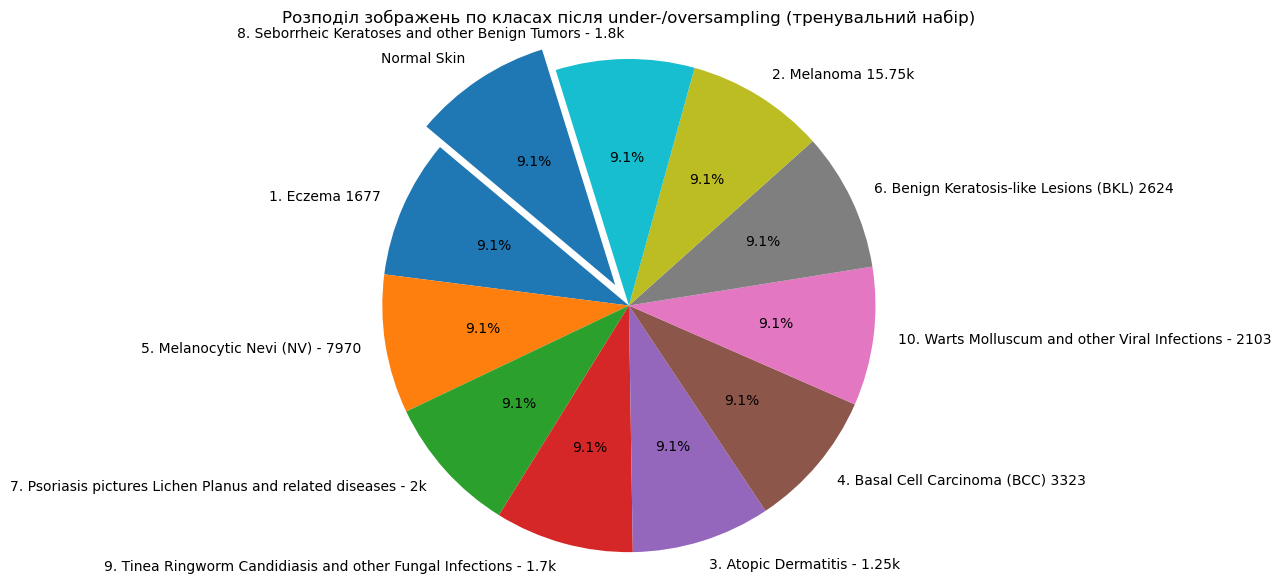

In [ ]:
train_path = "/home/jovyan/work/dataset/train"
class_counts_after = {}
for class_dir in os.listdir(train_path):
    class_path = os.path.join(train_path, class_dir)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts_after[class_dir] = count

total_images_after = sum(class_counts_after.values())
class_percentages_after = {k: (v / total_images_after) * 100 for k, v in class_counts_after.items()}

sorted_counts_after = dict(sorted(class_counts_after.items(), key=lambda x: x[1], reverse=True))
sorted_percentages_after = {k: class_percentages_after[k] for k in sorted_counts_after.keys()}

print("Розподіл зображень по класах після under-/oversampling (тренувальний набір):")
for name, count in sorted_counts_after.items():
    print(f"{name}: {count} зображень ({sorted_percentages_after[name]:.2f}%)")

labels_after = list(sorted_percentages_after.keys())
sizes_after = list(sorted_percentages_after.values())
explode_after = [0.1 if label == "Normal Skin" else 0 for label in labels_after]

plt.figure(figsize=(7, 7))
plt.pie(sizes_after, labels=labels_after, autopct='%1.1f%%', startangle=140, explode=explode_after)
plt.axis('equal')
plt.title("Розподіл зображень по класах після under-/oversampling (тренувальний набір)")
plt.show()

In [ ]:
def check_dataset(train_path, val_path, test_path):
    """
    Перевірка розмірів класів у тренувальному, валідаційному та тестовому наборах даних.

    Ця функція виводить кількість зображень у кожному класі для всіх трьох наборів даних,
    щоб переконатися, що датасет підготовлено правильно.

    :param train_path: Шлях до директорії з тренувальним набором.
    :param val_path: Шлях до директорії з валідаційним набором.
    :param test_path: Шлях до директорії з тестовим набором.
    """
    print("Тренувальний датасет:")
    for class_dir in os.listdir(train_path):
        class_path = os.path.join(train_path, class_dir)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            print(f"{class_dir}: {num_files} зображень")

    print("\nВалідаційний датасет:")
    for class_dir in os.listdir(val_path):
        class_path = os.path.join(val_path, class_dir)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            print(f"{class_dir}: {num_files} зображень")

    print("\nТестовий датасет:")
    for class_dir in os.listdir(test_path):
        class_path = os.path.join(test_path, class_dir)
        if os.path.isdir(class_path):
            num_files = len(os.listdir(class_path))
            print(f"{class_dir}: {num_files} зображень")

check_dataset(
    "/home/jovyan/work/dataset/train",
    "/home/jovyan/work/dataset/validation",
    "/home/jovyan/work/dataset/test"
)

Тренувальний датасет:
1. Eczema 1677: 2400 зображень
5. Melanocytic Nevi (NV) - 7970: 2400 зображень
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 2400 зображень
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 2400 зображень
3. Atopic Dermatitis - 1.25k: 2400 зображень
4. Basal Cell Carcinoma (BCC) 3323: 2400 зображень
10. Warts Molluscum and other Viral Infections - 2103: 2400 зображень
6. Benign Keratosis-like Lesions (BKL) 2624: 2400 зображень
2. Melanoma 15.75k: 2400 зображень
8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 2400 зображень
Normal Skin: 2400 зображень

Валідаційний датасет:
1. Eczema 1677: 800 зображень
5. Melanocytic Nevi (NV) - 7970: 800 зображень
7. Psoriasis pictures Lichen Planus and related diseases - 2k: 800 зображень
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 800 зображень
3. Atopic Dermatitis - 1.25k: 800 зображень
4. Basal Cell Carcinoma (BCC) 3323: 800 зображень
10. Warts Molluscum and other

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import numpy as np

seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    rotation_range=50,
    width_shift_range=0.35,
    height_shift_range=0.35,
    shear_range=0.35,
    zoom_range=0.35,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.5, 1.5],
    channel_shift_range=30.0,
    fill_mode='nearest',
    preprocessing_function=lambda x: x * (0.8 + 0.4 * random.random())
)

val_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    "/home/jovyan/work/dataset/train",
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    "/home/jovyan/work/dataset/validation",
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_indices = train_generator.class_indices
print(f"Індекси класів: {class_indices}")

# Повернутися пізніше

# class_weights = {}
# total_samples = sum([len(os.listdir(os.path.join("/home/jovyan/work/dataset/train", d)))
#                      for d in os.listdir("/home/jovyan/work/dataset/train")
#                      if os.path.isdir(os.path.join("/home/jovyan/work/dataset/train", d))])
# print(f"Загальна кількість тренувальних зображень: {total_samples}")

# for class_name, class_idx in class_indices.items():
#     class_count = len(os.listdir(os.path.join("/home/jovyan/work/dataset/train", class_name)))
#     class_weights[class_idx] = total_samples / class_count
#     if class_name == "Normal Skin":
#         class_weights[class_idx] = 15.0
#     elif class_name == "7. Psoriasis pictures Lichen Planus and related diseases - 2k":
#         class_weights[class_idx] = 20.0
#     elif class_name == "1. Eczema 1677":
#         class_weights[class_idx] = 15.0
#     elif class_name == "3. Atopic Dermatitis - 1.25k":
#         class_weights[class_idx] = 15.0
#     print(f"Клас {class_name}: {class_count} зображень, вага={class_weights[class_idx]:.2f}")

Found 26400 images belonging to 11 classes.
Found 8800 images belonging to 11 classes.
Індекси класів: {'1. Eczema 1677': 0, '10. Warts Molluscum and other Viral Infections - 2103': 1, '2. Melanoma 15.75k': 2, '3. Atopic Dermatitis - 1.25k': 3, '4. Basal Cell Carcinoma (BCC) 3323': 4, '5. Melanocytic Nevi (NV) - 7970': 5, '6. Benign Keratosis-like Lesions (BKL) 2624': 6, '7. Psoriasis pictures Lichen Planus and related diseases - 2k': 7, '8. Seborrheic Keratoses and other Benign Tumors - 1.8k': 8, '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k': 9, 'Normal Skin': 10}


In [ ]:
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models

base_model = MobileNetV3Small(
    input_shape=(299, 299, 3),
    alpha=1.0,
    minimalistic=False,
    include_top=False,
    weights='imagenet',
    dropout_rate=0.2,
    include_preprocessing=False
)

base_model.trainable = False
fine_tune_at = 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

x = base_model.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(512, activation='relu')(x)
predictions = tf.keras.layers.Dense(11, activation='softmax')(x)
model = tf.keras.models.Model(inputs=base_model.input, outputs=predictions)

model.summary()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

I0000 00:00:1745076825.552674  224739 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11857 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast (Cast)         │ (None, 299, 299,  │          0 │ input_layer[0][0] │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv (Conv2D)       │ (None, 150, 150,  │        432 │ cast[0][0]        │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv_bn             │ (None, 150, 150,  │         64 │ conv[0][0]        │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 150, 150,  │          0 │ conv_bn[0][0]     │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 151, 151,  │          0 │ activation[0][0]  │
│ (ZeroPadding2D)     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │        144 │ expanded_conv_de… │
│ (DepthwiseConv2D)   │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 75, 75,    │         64 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 75, 75,    │          0 │ expanded_conv_de… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │          0 │ re_lu[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │        136 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 8)   │          0 │ expanded_conv_sq… │
│ (ReLU)              │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 1, 1, 16)  │        144 │ expanded_conv_sq… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 1, 1, 16)  │          0 │ expanded_conv_sq… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 1, 1, 16)  │          0 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 1, 1, 16)  │          0 │ re_lu_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_sque… │ (None, 75, 75,    │          0 │ re_lu[0][0],      │
│ (Multiply)          │ 16)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 75, 75,    │        256 │ expanded_conv_sq

 Total params: 1,240,187 (4.73 MB)

 Trainable params: 301,067 (1.15 MB)

 Non-trainable params: 939,120 (3.58 MB)

In [ ]:
checkpoint_initial = ModelCheckpoint(
    "/home/jovyan/work/checkpoints/model_initial_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr_initial = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

early_stopping_initial = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [ ]:
history_initial = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    verbose=1,
    callbacks=[checkpoint_initial, reduce_lr_initial, early_stopping_initial]
)

Epoch 1/15


I0000 00:00:1745076828.387851  226067 service.cc:152] XLA service 0x7f93c40031f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745076828.387875  226067 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
I0000 00:00:1745076828.805046  226067 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/825 ━━━━━━━━━━━━━━━━━━━━ 1:38:24 7s/step - accuracy: 0.1250 - loss: 2.5531 - precision: 0.0000e+00 - recall: 0.0000e+00

I0000 00:00:1745076833.824678  226067 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.3658 - loss: 1.9003 - precision: 0.7125 - recall: 0.0915
Epoch 1: val_accuracy improved from -inf to 0.70125, saving model to /home/jovyan/work/checkpoints/model_initial_best.keras
825/825 ━━━━━━━━━━━━━━━━━━━━ 213s 249ms/step - accuracy: 0.3660 - loss: 1.8999 - precision: 0.7126 - recall: 0.0916 - val_accuracy: 0.7013 - val_loss: 0.9118 - val_precision: 0.8549 - val_recall: 0.5830 - learning_rate: 1.0000e-04
Epoch 2/15
825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.6164 - loss: 1.1959 - precision: 0.8032 - recall: 0.4014
Epoch 2: val_accuracy improved from 0.70125 to 0.73182, saving model to /home/jovyan/work/checkpoints/model_initial_best.keras
825/825 ━━━━━━━━━━━━━━━━━━━━ 202s 245ms/step - accuracy: 0.6164 - loss: 1.1959 - precision: 0.8032 - recall: 0.4014 - val_accuracy: 0.7318 - val_loss: 0.7970 - val_precision: 0.8661 - val_recall: 0.6343 - learning_rate: 1.0000e-04
Epoch 3/15
825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms

In [ ]:
print(f"Точність на валідації: {history_initial.history['val_accuracy'][-1]:.4f}")
print(f"Precision на валідації: {history_initial.history['val_precision'][-1]:.4f}")
print(f"Recall на валідації: {history_initial.history['val_recall'][-1]:.4f}")

Точність на валідації: 0.7751
Precision на валідації: 0.9098
Recall на валідації: 0.6784


In [ ]:
base_model.trainable = True
fine_tune_at = 40
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy', tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

checkpoint_fine = ModelCheckpoint(
    "/home/jovyan/work/checkpoints/model_fine_best.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

reduce_lr_fine = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

early_stopping_fine = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

history_fine = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    verbose=1,
    callbacks=[checkpoint_fine, reduce_lr_fine, early_stopping_fine]
)

Epoch 1/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 253ms/step - accuracy: 0.4049 - loss: 1.9444 - precision_1: 0.5659 - recall_1: 0.2644
Epoch 1: val_accuracy improved from -inf to 0.74795, saving model to /home/jovyan/work/checkpoints/model_fine_best.keras
825/825 ━━━━━━━━━━━━━━━━━━━━ 244s 272ms/step - accuracy: 0.4050 - loss: 1.9438 - precision_1: 0.5660 - recall_1: 0.2645 - val_accuracy: 0.7480 - val_loss: 0.6845 - val_precision_1: 0.8643 - val_recall_1: 0.6885 - learning_rate: 2.0000e-05
Epoch 2/50
825/825 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 0.6721 - loss: 0.9121 - precision_1: 0.8106 - recall_1: 0.5714
Epoch 2: val_accuracy improved from 0.74795 to 0.76875, saving model to /home/jovyan/work/checkpoints/model_fine_best.keras
825/825 ━━━━━━━━━━━━━━━━━━━━ 201s 243ms/step - accuracy: 0.6721 - loss: 0.9121 - precision_1: 0.8107 - recall_1: 0.5714 - val_accuracy: 0.7688 - val_loss: 0.6100 - val_precision_1: 0.8964 - val_recall_1: 0.6914 - learning_rate: 2.0000e-05
Epoch 3/50
825/825 

In [ ]:
print(f"Fine Tuning - точність на валідації: {history_fine.history['val_accuracy'][-1]:.4f}")
print(f"Fine Tuning - precision на валідації: {history_fine.history['val_precision_1'][-1]:.4f}")
print(f"Fine Tuning - recall на валідації: {history_fine.history['val_recall_1'][-1]:.4f}")

Fine Tuning - точність на валідації: 0.8473
Fine Tuning - precision на валідації: 0.9292
Fine Tuning - recall на валідації: 0.7948


In [ ]:
seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

import os
import random
import shutil
from concurrent.futures import ThreadPoolExecutor

def copy_file(src_dst):
    """Копіює один файл з джерела до цілі."""
    src, dst = src_dst
    try:
        shutil.copy2(src, dst)
    except Exception as e:
        print(f"Помилка копіювання {src} до {dst}: {e}")

def create_balanced_test_set(test_path, balanced_test_path, test_size_per_class=25):
    """
    Створює збалансований тестовий набір, копіюючи задану кількість зображень для кожного класу.

    :param test_path: Шлях до початкової тестової директорії з класами.
    :param balanced_test_path: Шлях до директорії для збалансованого тестового набору.
    :param test_size_per_class: Кількість зображень для кожного класу (за замовчуванням 25).
    """
    # Видаляємо цільову директорію, якщо вона існує, і створюємо нову
    if os.path.exists(balanced_test_path):
        shutil.rmtree(balanced_test_path)
    os.makedirs(balanced_test_path, exist_ok=True)

    for class_dir in os.listdir(test_path):
        class_path = os.path.join(test_path, class_dir)
        if os.path.isdir(class_path):
            # Збираємо список зображень
            images = [img for img in os.listdir(class_path) if img.endswith(('.jpg', '.png', '.jpeg'))]
            if len(images) < test_size_per_class:
                print(f"Недостатньо зображень для {class_dir}: {len(images)} доступно")
                continue
            # Вибираємо випадкову підмножину зображень
            images = random.sample(images, test_size_per_class)

            # Створюємо директорію для класу в збалансованому наборі
            balanced_class_path = os.path.join(balanced_test_path, class_dir)
            os.makedirs(balanced_class_path, exist_ok=True)

            # Готуємо пари джерело-ціль для копіювання
            src_dst_pairs = [(os.path.join(class_path, img),
                              os.path.join(balanced_class_path, img))
                             for img in images]

            # Використовуємо ThreadPoolExecutor для паралельного копіювання
            with ThreadPoolExecutor(max_workers=4) as executor:  # max_workers можна налаштувати
                executor.map(copy_file, src_dst_pairs)

            print(f"Скопійовано для {class_dir}: {test_size_per_class} у збалансований тестовий набір")

create_balanced_test_set(
    "/home/jovyan/work/dataset/test",
    "/home/jovyan/work/dataset/balanced_test",
    test_size_per_class=50
)

Скопійовано для 1. Eczema 1677: 50 у збалансований тестовий набір
Скопійовано для 5. Melanocytic Nevi (NV) - 7970: 50 у збалансований тестовий набір
Скопійовано для 7. Psoriasis pictures Lichen Planus and related diseases - 2k: 50 у збалансований тестовий набір
Скопійовано для 9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k: 50 у збалансований тестовий набір
Скопійовано для 3. Atopic Dermatitis - 1.25k: 50 у збалансований тестовий набір
Скопійовано для 4. Basal Cell Carcinoma (BCC) 3323: 50 у збалансований тестовий набір
Скопійовано для 10. Warts Molluscum and other Viral Infections - 2103: 50 у збалансований тестовий набір
Скопійовано для 6. Benign Keratosis-like Lesions (BKL) 2624: 50 у збалансований тестовий набір
Скопійовано для 2. Melanoma 15.75k: 50 у збалансований тестовий набір
Скопійовано для 8. Seborrheic Keratoses and other Benign Tumors - 1.8k: 50 у збалансований тестовий набір
Скопійовано для Normal Skin: 50 у збалансований тестовий набір


In [ ]:
test_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    "/home/jovyan/work/dataset/test",
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 8800 images belonging to 11 classes.


In [ ]:
test_generator.reset()
test_loss, test_accuracy, test_precision, test_recall = model.evaluate(test_generator)
print(f"Точність на тестовому наборі: {test_accuracy:.4f}")
print(f"Precision на тестовому наборі: {test_precision:.4f}")
print(f"Recall на тестовому наборі: {test_recall:.4f}")

275/275 ━━━━━━━━━━━━━━━━━━━━ 15s 52ms/step - accuracy: 0.8356 - loss: 0.4302 - precision_1: 0.9284 - recall_1: 0.7814
Точність на тестовому наборі: 0.8509
Precision на тестовому наборі: 0.9277
Recall на тестовому наборі: 0.7972


In [ ]:
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred_classes)
print("Confusion Matrix для тестового набору:")
print(cm)

class_names = list(test_generator.class_indices.keys())
print(f"Класи: {class_names}")

precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred_classes, average=None)
for i, class_name in enumerate(class_names):
    print(f"Клас {class_name}:")
    print(f"  Precision: {precision[i]:.4f}")
    print(f"  Recall: {recall[i]:.4f}")
    print(f"  F1-Score: {f1[i]:.4f}")

275/275 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step
Confusion Matrix для тестового набору:
[[619  36   0  11   0   0   0  81  20  33   0]
 [ 24 644   2  21   0   0   0  53  32  24   0]
 [  0   0 781   0   0  15   0   1   3   0   0]
 [ 45  56   0 606   0   0   0  55  11  26   1]
 [  0   0   1   0 723  10  66   0   0   0   0]
 [  0   1  47   0  10 687  53   0   2   0   0]
 [  0   0   6   0  65  18 707   0   4   0   0]
 [ 38  44   0   7   0   1   0 615  26  69   0]
 [  3  51   1   8   0   3   5  45 664  20   0]
 [ 31  26   0   5   0   0   0  68  24 645   1]
 [  0   0   1   0   0   0   0   1   0   1 797]]
Класи: ['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm C